## schema survey

In [3]:
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import defaultdict, Counter
import re
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DEBATES_DIR = Path("data/debates")
ALL_FILES = sorted(DEBATES_DIR.glob("debates*.xml"))
print(f"Found {len(ALL_FILES)} files")

Found 20021 files


In [4]:
def sample_files(files, per_decade=5, seed=42):
    random.seed(seed)
    by_decade = defaultdict(list)
    for f in files:
        m = re.search(r'(\d{4})', f.stem)
        if m:
            decade = (int(m.group(1)) // 10) * 10
            by_decade[decade].append(f)
    sampled = []
    for decade in sorted(by_decade):
        candidates = by_decade[decade]
        sampled.extend(random.sample(candidates, min(per_decade, len(candidates))))
    return sampled

def survey_file(path):
    m = re.search(r'(\d{4})', path.stem)
    year = m.group(1) if m else "????"
    try:
        root = ET.parse(path).getroot()
    except ET.ParseError as e:
        return {"file": path.name, "year": year, "error": str(e)}

    tag_attrs = defaultdict(set)
    for el in root.iter():
        tag_attrs[el.tag].update(el.attrib.keys())

    speech_tags = {t: a for t, a in tag_attrs.items()
                   if any(k in t.lower() for k in ("speech", "question", "answer", "oral", "written"))}

    speech_sample = {}
    for tag in speech_tags:
        el = root.find(f".//{tag}")
        if el is not None:
            speech_sample[tag] = dict(el.attrib)
            break

    return {
        "file": path.name,
        "year": year,
        "root_tag": root.tag,
        "all_tags": sorted(tag_attrs.keys()),
        "speech_tags": {t: sorted(a) for t, a in speech_tags.items()},
        "speech_sample": speech_sample,
    }

survey_sample = sample_files(ALL_FILES, per_decade=5)
survey_results = [survey_file(f) for f in survey_sample]

print(f"Surveyed {len(survey_results)} files\n")
for r in survey_results:
    if "error" in r:
        print(f"  ERROR {r['file']}: {r['error']}")
    else:
        print(f"  {r['year']}  {r['file']:<50}  root=<{r['root_tag']}>  tags={list(r['speech_tags'].keys())}")

Surveyed 60 files

  1919  debates1919-03-19a.xml                              root=<publicwhip>  tags=['speech']
  1919  debates1919-02-14a.xml                              root=<publicwhip>  tags=['speech']
  1919  debates1919-05-30a.xml                              root=<publicwhip>  tags=['speech']
  1919  debates1919-05-19a.xml                              root=<publicwhip>  tags=['speech']
  1919  debates1919-05-12a.xml                              root=<publicwhip>  tags=['speech']
  1922  debates1922-07-14a.xml                              root=<publicwhip>  tags=['speech']
  1922  debates1922-03-03a.xml                              root=<publicwhip>  tags=['speech']
  1921  debates1921-06-27a.xml                              root=<publicwhip>  tags=['speech']
  1927  debates1927-12-15a.xml                              root=<publicwhip>  tags=['speech']
  1920  debates1920-06-17a.xml                              root=<publicwhip>  tags=['speech']
  1930  debates1930-04-16a.xml 

In [5]:
tag_years = defaultdict(list)
for r in survey_results:
    if "error" not in r:
        for tag in r["speech_tags"]:
            tag_years[tag].append(r["year"])

print("--- Speech tag presence by year ---")
for tag, yrs in sorted(tag_years.items()):
    print(f"  <{tag}>: {sorted(yrs)}")

print("\n--- Sample speech attributes by year ---")
for r in survey_results:
    if "error" not in r and r["speech_sample"]:
        for tag, attrs in r["speech_sample"].items():
            print(f"  {r['year']}  <{tag}> attrs: {attrs}")

print("\n--- All unique tags seen across sample ---")
all_tags = sorted({t for r in survey_results if "error" not in r for t in r["all_tags"]})
print(" ", ", ".join(all_tags))

--- Speech tag presence by year ---
  <oral-heading>: ['2003', '2006', '2008', '2011', '2015']
  <speech>: ['1919', '1919', '1919', '1919', '1919', '1920', '1921', '1922', '1922', '1927', '1930', '1931', '1932', '1933', '1936', '1940', '1943', '1948', '1949', '1949', '1953', '1955', '1956', '1957', '1959', '1960', '1962', '1963', '1967', '1969', '1972', '1973', '1974', '1975', '1978', '1981', '1981', '1982', '1984', '1989', '1991', '1994', '1994', '1994', '1997', '2001', '2003', '2006', '2008', '2009', '2011', '2015', '2018', '2019', '2020', '2022', '2025', '2026']

--- Sample speech attributes by year ---
  1919  <speech> attrs: {'id': 'uk.org.publicwhip/debate/1919-03-19a.2063.1', 'colnum': '2063', 'url': 'https://api.parliament.uk/historic-hansard/commons/1919/mar/19/preamble#S5CV0113P0_19190319_HOC_1'}
  1919  <speech> attrs: {'id': 'uk.org.publicwhip/debate/1919-02-14a.437.1', 'colnum': '437', 'url': 'https://api.parliament.uk/historic-hansard/commons/1919/feb/14/preamble#S5CV0112

In [6]:
file_counts_by_year = defaultdict(int)
for f in ALL_FILES:
    m = re.search(r'(\d{4})', f.stem)
    if m:
        file_counts_by_year[int(m.group(1))] += 1

survey_years = sorted(file_counts_by_year)
print(f"Year range: {survey_years[0]}–{survey_years[-1]}")
print(f"Years with data: {len(survey_years)}")

all_years_range = set(range(survey_years[0], survey_years[-1] + 1))
gaps = sorted(all_years_range - set(survey_years))
print(f"Gaps: {gaps if gaps else 'none'}")

Year range: 1919–2026
Years with data: 108
Gaps: none


In [7]:
counts = [file_counts_by_year[y] for y in survey_years]

print(f"Total files:  {sum(counts):,}")
print(f"Mean:         {np.mean(counts):.1f}")
print(f"Median:       {np.median(counts):.1f}")
print(f"Std dev:      {np.std(counts):.1f}")
print(f"Min:          {min(counts)}  ({survey_years[counts.index(min(counts))]})")
print(f"Max:          {max(counts)}  ({survey_years[counts.index(max(counts))]})")

print("\nBottom 5 years:")
for y, c in sorted(file_counts_by_year.items(), key=lambda x: x[1])[:5]:
    print(f"  {y}: {c} files")

print("\nTop 5 years:")
for y, c in sorted(file_counts_by_year.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {y}: {c} files")

Total files:  20,021
Mean:         185.4
Median:       161.0
Std dev:      79.3
Min:          62  (1923)
Max:          474  (2025)

Bottom 5 years:
  1923: 62 files
  1921: 64 files
  1942: 98 files
  1924: 102 files
  1929: 102 files

Top 5 years:
  2025: 474 files
  2024: 443 files
  2020: 410 files
  2009: 373 files
  2008: 372 files


In [8]:
suffix_counts = Counter()
for f in ALL_FILES:
    m = re.search(r'\d{4}-\d{2}-\d{2}([a-z]*)', f.stem)
    if m:
        suffix_counts[m.group(1) or "none"] += 1

print("File suffix breakdown:")
for suffix, count in sorted(suffix_counts.items(), key=lambda x: -x[1]):
    print(f"  '{suffix}': {count:,} files")

File suffix breakdown:
  'a': 15,502 files
  'b': 2,294 files
  'c': 1,005 files
  'none': 623 files
  'd': 393 files
  'e': 147 files
  'f': 44 files
  'g': 10 files
  'h': 2 files
  'i': 1 files


In [9]:
file_records = []
for f in ALL_FILES:
    m = re.search(r'(\d{4}-\d{2}-\d{2})([a-z]*)', f.stem)
    if not m:
        continue
    date, suffix = m.group(1), m.group(2) or "none"
    year = int(date[:4])
    try:
        root = ET.parse(f).getroot()
    except ET.ParseError:
        continue

    speeches = root.findall(".//speech")
    n_speeches = len(speeches)
    word_counts = []
    has_speaker = 0
    has_time = 0
    has_type = 0
    speaker_ids = set()

    for s in speeches:
        text = " ".join(p.text or "" for p in s.findall(".//p") if p.text)
        word_counts.append(len(text.split()))
        if s.get("speakername") or s.get("speakerid") or s.get("person_id"):
            has_speaker += 1
        if s.get("time"):
            has_time += 1
        if s.get("type"):
            has_type += 1
        pid = s.get("person_id") or s.get("speakerid")
        if pid:
            speaker_ids.add(pid)

    file_records.append({
        "file": f.name,
        "date": date,
        "year": year,
        "suffix": suffix,
        "n_speeches": n_speeches,
        "total_words": sum(word_counts),
        "mean_words": np.mean(word_counts) if word_counts else 0,
        "max_words": max(word_counts) if word_counts else 0,
        "pct_speaker": 100 * has_speaker / n_speeches if n_speeches else 0,
        "pct_time": 100 * has_time / n_speeches if n_speeches else 0,
        "pct_type": 100 * has_type / n_speeches if n_speeches else 0,
        "n_speakers": len(speaker_ids),
    })

print(f"Parsed {len(file_records)} files")

Parsed 20021 files


In [10]:
by_year_agg = defaultdict(lambda: defaultdict(list))
for r in file_records:
    y = r["year"]
    for k in ("n_speeches", "total_words", "mean_words", "pct_speaker", "n_speakers"):
        by_year_agg[y][k].append(r[k])

agg_years = sorted(by_year_agg)
yspeeches = [sum(by_year_agg[y]["n_speeches"]) for y in agg_years]
ywords    = [sum(by_year_agg[y]["total_words"]) for y in agg_years]
yspeaker  = [np.mean(by_year_agg[y]["pct_speaker"]) for y in agg_years]
ymean_wds = [np.mean(by_year_agg[y]["mean_words"]) for y in agg_years]

total_speeches = sum(r["n_speeches"] for r in file_records)
total_words    = sum(r["total_words"] for r in file_records)
all_mean_words = [r["mean_words"] for r in file_records if r["mean_words"] > 0]

print("=" * 55)
print("  HANSARD CORPUS SUMMARY")
print("=" * 55)
print(f"  Files parsed:        {len(file_records):>10,}")
print(f"  Total speeches:      {total_speeches:>10,}")
print(f"  Total words:         {total_words:>10,}")
print(f"  Avg words/speech:    {np.mean(all_mean_words):>10.1f}")
print(f"  Year range:          {agg_years[0]}–{agg_years[-1]}")

print("\n  Top 5 most verbose years (total words):")
for y, w in sorted(zip(agg_years, ywords), key=lambda x: -x[1])[:5]:
    print(f"    {y}: {w:,}")

print("\n  Top 5 years by speech count:")
for y, s in sorted(zip(agg_years, yspeeches), key=lambda x: -x[1])[:5]:
    print(f"    {y}: {s:,}")

print("\n  Speaker metadata coverage:")
early = np.mean([r["pct_speaker"] for r in file_records if r["year"] < 1990])
modern = np.mean([r["pct_speaker"] for r in file_records if r["year"] >= 2000])
print(f"    Pre-1990:   {early:.1f}%")
print(f"    Post-2000:  {modern:.1f}%")

  HANSARD CORPUS SUMMARY
  Files parsed:            20,021
  Total speeches:       6,944,177
  Total words:         534,877,188
  Avg words/speech:         138.8
  Year range:          1919–2026

  Top 5 most verbose years (total words):
    2009: 12,413,292
    2007: 11,985,091
    2008: 11,684,715
    2011: 10,968,249
    2006: 10,847,599

  Top 5 years by speech count:
    1947: 91,813
    1968: 88,017
    1967: 86,872
    1976: 86,757
    1972: 86,612

  Speaker metadata coverage:
    Pre-1990:   81.5%
    Post-2000:  86.9%


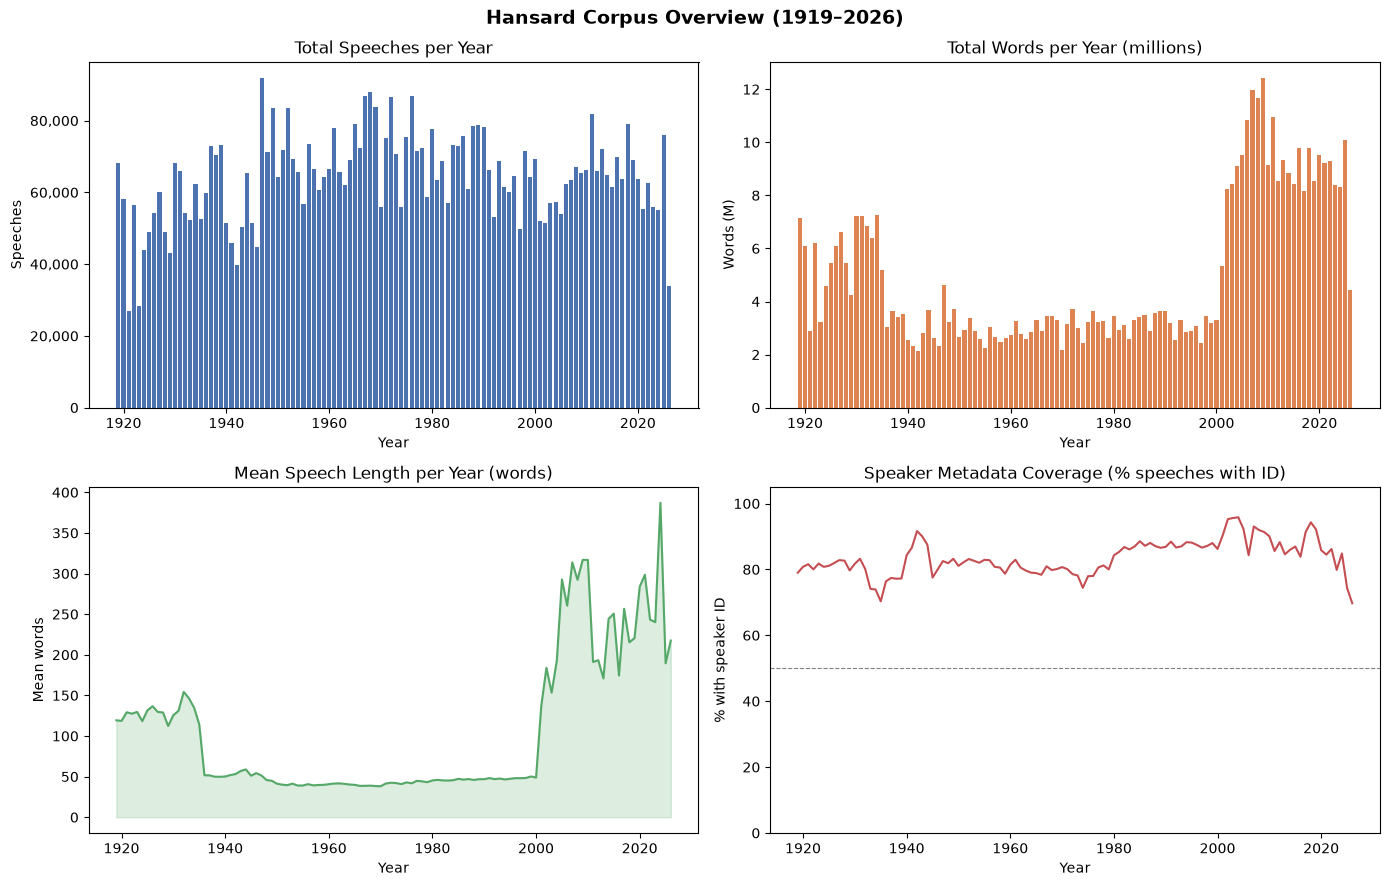

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Hansard Corpus Overview (1919–2026)", fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.bar(agg_years, yspeeches, color="#4C72B0", width=0.8)
ax.set_title("Total Speeches per Year")
ax.set_xlabel("Year"); ax.set_ylabel("Speeches")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax = axes[0, 1]
ax.bar(agg_years, [w / 1e6 for w in ywords], color="#DD8452", width=0.8)
ax.set_title("Total Words per Year (millions)")
ax.set_xlabel("Year"); ax.set_ylabel("Words (M)")

ax = axes[1, 0]
ax.plot(agg_years, ymean_wds, color="#55A868", linewidth=1.5)
ax.fill_between(agg_years, ymean_wds, alpha=0.2, color="#55A868")
ax.set_title("Mean Speech Length per Year (words)")
ax.set_xlabel("Year"); ax.set_ylabel("Mean words")

ax = axes[1, 1]
ax.plot(agg_years, yspeaker, color="#C44E52", linewidth=1.5)
ax.axhline(50, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Speaker Metadata Coverage (% speeches with ID)")
ax.set_xlabel("Year"); ax.set_ylabel("% with speaker ID")
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig("hansard_overview.png", dpi=150, bbox_inches="tight")
plt.show()

# Basix Text Analysis

In [15]:
import re
from collections import defaultdict, Counter
import random

STOPWORDS = set("""
a about above after again against all am an and any are aren't as at be because
been before being below between both but by can't cannot could couldn't did
didn't do does doesn't doing don't down during each few for from further had
hadn't has hasn't have haven't having he he'd he'll he's her here here's hers
herself him himself his how how's i i'd i'll i'm i've if in into is isn't it
it's its itself let's me more most mustn't my myself no nor not of off on once
only or other ought our ours ourselves out over own same shan't she she'd
she'll she's should shouldn't so some such than that that's the their theirs
them themselves then there there's these they they'd they'll they're they've
this those through to too under until up very was wasn't we we'd we'll we're
we've were weren't what what's when when's where where's which while who who's
whom why why's with won't would wouldn't you you'd you'll you're you've your
yours yourself yourselves hon honourable member gentleman friend house will
""".split())

def extract_text(file_path):
    """Returns the full concatenated speech text of a debate file."""
    try:
        root = ET.parse(file_path).getroot()
    except ET.ParseError:
        return ""
    parts = []
    for s in root.findall(".//speech"):
        for p in s.findall(".//p"):
            if p.text:
                parts.append(p.text)
    return " ".join(parts)

def sample_files_per_decade(files, n=15, seed=42):
    random.seed(seed)
    by_decade = defaultdict(list)
    for f in files:
        m = re.search(r'(\d{4})', f.stem)
        if m:
            decade = (int(m.group(1)) // 10) * 10
            by_decade[decade].append(f)
    sampled = {}
    for decade, candidates in by_decade.items():
        sampled[decade] = random.sample(candidates, min(n, len(candidates)))
    return sampled

decade_samples = sample_files_per_decade(ALL_FILES, n=15)
print(f"Sampled decades: {sorted(decade_samples.keys())}")
print(f"Files per decade: {[(d, len(f)) for d, f in sorted(decade_samples.items())]}")

Sampled decades: [1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020]
Files per decade: [(1910, 15), (1920, 15), (1930, 15), (1940, 15), (1950, 15), (1960, 15), (1970, 15), (1980, 15), (1990, 15), (2000, 15), (2010, 15), (2020, 15)]


In [16]:
decade_word_freq = {}

for decade, files in sorted(decade_samples.items()):
    counter = Counter()
    for f in files:
        text = extract_text(f).lower()
        words = re.findall(r"[a-z']+", text)
        words = [w for w in words if w not in STOPWORDS and len(w) > 2]
        counter.update(words)
    decade_word_freq[decade] = counter

print("Top 10 words by decade:\n")
for decade in sorted(decade_word_freq):
    top = decade_word_freq[decade].most_common(10)
    words_str = ", ".join(f"{w}({c})" for w, c in top)
    print(f"  {decade}s: {words_str}")

Top 10 words by decade:

  1910s: government(2258), whether(1700), right(1678), one(1612), bill(1611), war(1564), can(1522), question(1492), think(1357), may(1302)
  1920s: bill(2080), one(1835), government(1751), right(1722), question(1646), can(1581), think(1547), may(1524), made(1403), whether(1353)
  1930s: right(1652), government(1650), bill(1649), one(1580), can(1356), whether(1216), may(1186), question(1161), country(1121), made(1054)
  1940s: right(1327), minister(974), whether(963), asked(884), can(848), government(796), question(792), one(792), war(779), made(774)
  1950s: right(1037), minister(719), one(600), can(598), think(558), time(552), made(532), asked(503), may(502), matter(500)
  1960s: right(1495), order(1049), government(1008), point(888), one(877), minister(860), can(769), made(710), question(705), asked(669)
  1970s: right(1629), government(931), minister(811), order(738), one(737), can(680), point(663), time(626), made(622), secretary(614)
  1980s: right(1293), 

In [14]:
hapax_results = {}

for decade, files in sorted(decade_samples.items()):
    counter = Counter()
    for f in files:
        text = extract_text(f).lower()
        words = re.findall(r"[a-z']+", text)
        counter.update(words)

    total_tokens = sum(counter.values())
    total_types = len(counter)
    hapax_count = sum(1 for w, c in counter.items() if c == 1)
    hapax_rate = hapax_count / total_types if total_types else 0
    ttr = total_types / total_tokens if total_tokens else 0

    hapax_results[decade] = {
        "tokens": total_tokens,
        "types": total_types,
        "hapax_count": hapax_count,
        "hapax_rate": hapax_rate,
        "ttr": ttr,
    }

print(f"{'Decade':<8}{'Tokens':>10}{'Types':>10}{'Hapax':>10}{'Hapax%':>10}{'TTR':>8}")
for decade in sorted(hapax_results):
    r = hapax_results[decade]
    print(f"{decade}s{'':<4}{r['tokens']:>10,}{r['types']:>10,}{r['hapax_count']:>10,}{r['hapax_rate']*100:>9.1f}%{r['ttr']:>8.3f}")

Decade      Tokens     Types     Hapax    Hapax%     TTR
1910s       611,041    13,683     4,837     35.4%   0.022
1920s       655,586    14,589     5,116     35.1%   0.022
1930s       571,714    14,192     5,190     36.6%   0.025
1940s       335,319    11,440     4,209     36.8%   0.034
1950s       238,153     9,670     3,581     37.0%   0.041
1960s       344,658    11,563     4,295     37.1%   0.034
1970s       315,562    11,233     4,263     38.0%   0.036
1980s       282,758    11,492     4,400     38.3%   0.041
1990s       324,960    12,211     4,641     38.0%   0.038
2000s       569,989    16,474     6,012     36.5%   0.029
2010s       629,811    15,703     5,539     35.3%   0.025
2020s       397,077    13,259     4,987     37.6%   0.033


Decade     MeanWordLen   MeanSentLen  #Sentences
1910s              4.46          22.8      26,806
1920s              4.45          21.7      30,210
1930s              4.49          20.9      27,314
1940s              4.51          17.9      18,731
1950s              4.47          16.1      14,833
1960s              4.48          14.1      24,405
1970s              4.53          14.7      21,450
1980s              4.59          14.9      18,963
1990s              4.60          15.7      20,664
2000s              4.67          19.9      28,673
2010s              4.60          20.9      30,127
2020s              4.64          20.6      19,278


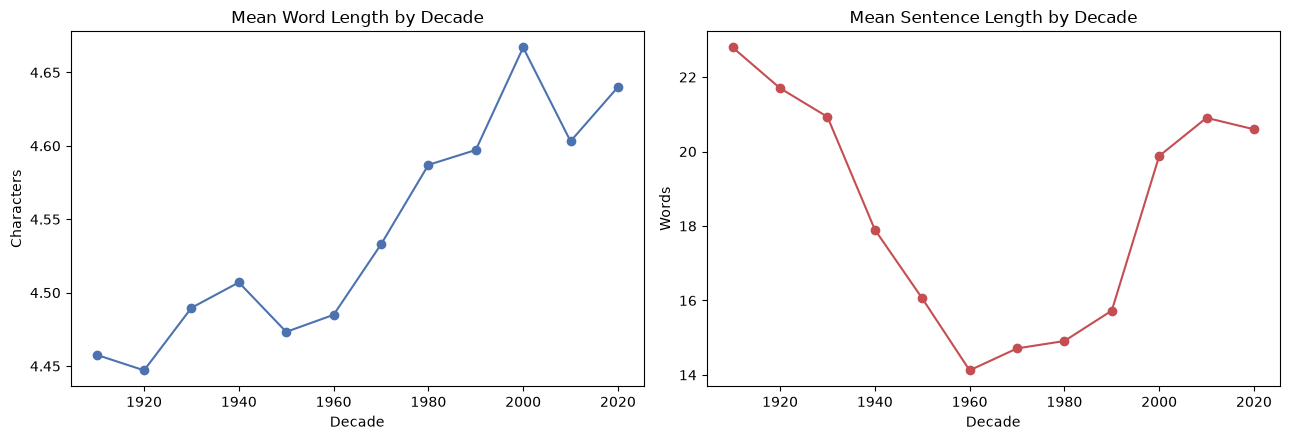

In [17]:
register_results = {}

for decade, files in sorted(decade_samples.items()):
    word_lengths = []
    sentence_lengths = []

    for f in files:
        text = extract_text(f)
        sentences = re.split(r'[.!?]+', text)
        for sent in sentences:
            words = re.findall(r"[A-Za-z']+", sent)
            if words:
                sentence_lengths.append(len(words))
                word_lengths.extend(len(w) for w in words)

    register_results[decade] = {
        "mean_word_len": np.mean(word_lengths) if word_lengths else 0,
        "mean_sent_len": np.mean(sentence_lengths) if sentence_lengths else 0,
        "n_sentences": len(sentence_lengths),
    }

print(f"{'Decade':<8}{'MeanWordLen':>14}{'MeanSentLen':>14}{'#Sentences':>12}")
for decade in sorted(register_results):
    r = register_results[decade]
    print(f"{decade}s{'':<4}{r['mean_word_len']:>14.2f}{r['mean_sent_len']:>14.1f}{r['n_sentences']:>12,}")

# Plot
decades_sorted = sorted(register_results)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(decades_sorted, [register_results[d]["mean_word_len"] for d in decades_sorted], marker="o", color="#4C72B0")
axes[0].set_title("Mean Word Length by Decade")
axes[0].set_xlabel("Decade"); axes[0].set_ylabel("Characters")

axes[1].plot(decades_sorted, [register_results[d]["mean_sent_len"] for d in decades_sorted], marker="o", color="#C44E52")
axes[1].set_title("Mean Sentence Length by Decade")
axes[1].set_xlabel("Decade"); axes[1].set_ylabel("Words")

plt.tight_layout()
plt.savefig("register_by_decade.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# Speeches per sitting day, by year — using file_records from the full parse

sitting_day_stats = defaultdict(lambda: {"days": set(), "total_speeches": 0, "total_words": 0})

for r in file_records:
    year = r["year"]
    sitting_day_stats[year]["days"].add(r["date"])
    sitting_day_stats[year]["total_speeches"] += r["n_speeches"]
    sitting_day_stats[year]["total_words"]    += r["total_words"]

years_sd = sorted(sitting_day_stats)
n_sitting_days     = [len(sitting_day_stats[y]["days"]) for y in years_sd]
speeches_per_day    = [sitting_day_stats[y]["total_speeches"] / len(sitting_day_stats[y]["days"]) for y in years_sd]
words_per_day        = [sitting_day_stats[y]["total_words"]    / len(sitting_day_stats[y]["days"]) for y in years_sd]
words_per_speech_day = [w / s if s else 0 for w, s in zip(words_per_day, speeches_per_day)]

print(f"{'Year':<6}{'SittingDays':>12}{'Speeches/Day':>14}{'Words/Day':>12}{'Words/Speech':>14}")
for y in years_sd[::5]:  # print every 5th year to keep it readable
    i = years_sd.index(y)
    print(f"{y:<6}{n_sitting_days[i]:>12}{speeches_per_day[i]:>14.1f}{words_per_day[i]:>12.0f}{words_per_speech_day[i]:>14.1f}")

Year   SittingDays  Speeches/Day   Words/Day  Words/Speech
1919           159         428.4       44919         104.8
1924           102         431.7       44890         104.0
1929           102         421.9       41751          99.0
1934           158         395.0       46059         116.6
1939           159         460.2       22286          48.4
1944           152         429.9       24206          56.3
1949           169         494.8       22064          44.6
1954           141         465.5       18369          39.5
1959           162         396.1       16154          40.8
1964           166         415.8       17271          41.5
1969           165         508.5       19951          39.2
1974           141         396.0       17152          43.3
1979           145         404.2       18026          44.6
1984           170         430.4       19372          45.0
1989           176         448.3       20792          46.4
1994           157         392.1       18055          46

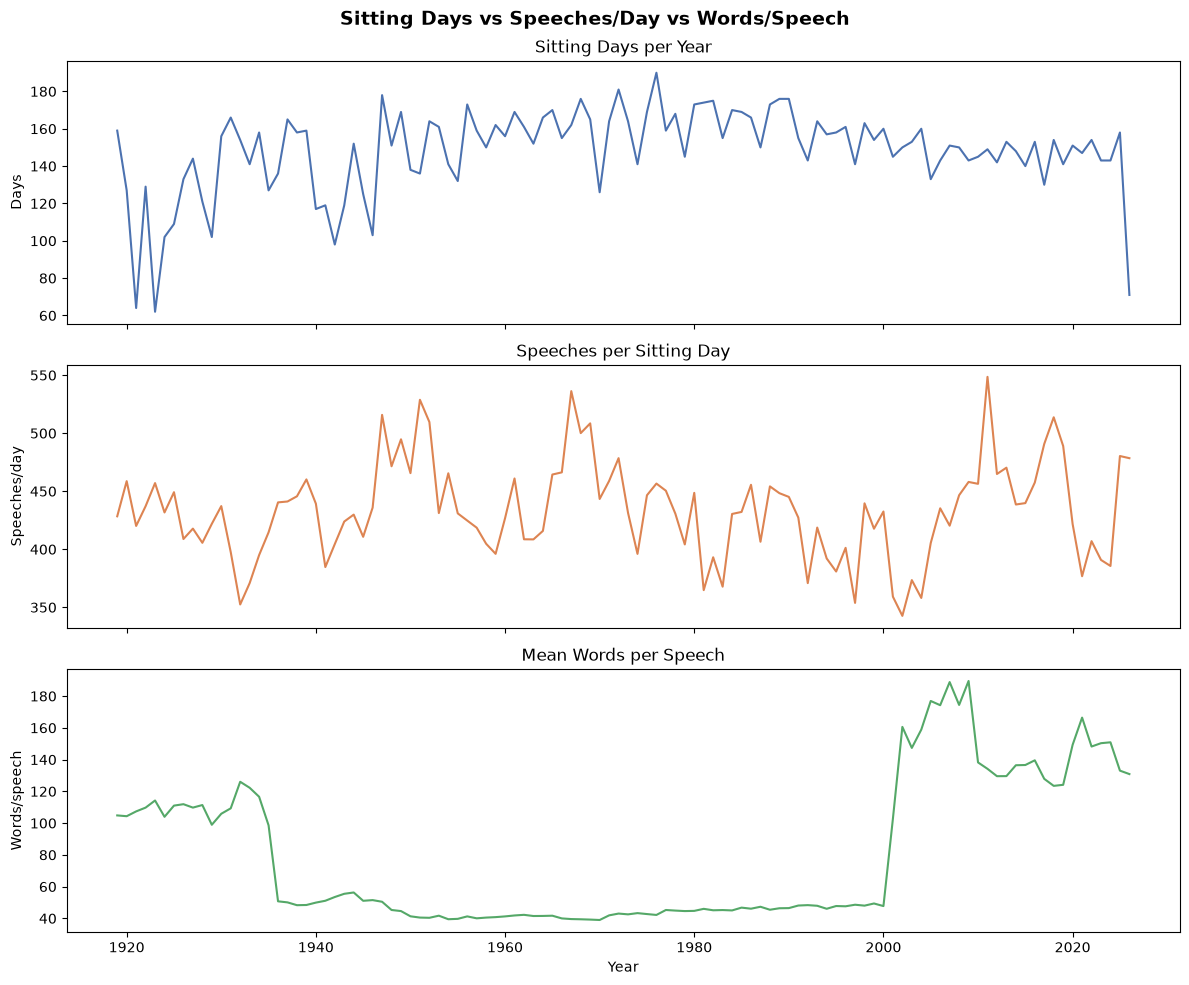

In [19]:
# Plot the three series together
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle("Sitting Days vs Speeches/Day vs Words/Speech", fontsize=14, fontweight="bold")

axes[0].plot(years_sd, n_sitting_days, color="#4C72B0")
axes[0].set_title("Sitting Days per Year")
axes[0].set_ylabel("Days")

axes[1].plot(years_sd, speeches_per_day, color="#DD8452")
axes[1].set_title("Speeches per Sitting Day")
axes[1].set_ylabel("Speeches/day")

axes[2].plot(years_sd, words_per_speech_day, color="#55A868")
axes[2].set_title("Mean Words per Speech")
axes[2].set_ylabel("Words/speech")
axes[2].set_xlabel("Year")

plt.tight_layout()
plt.savefig("sitting_day_analysis.png", dpi=150, bbox_inches="tight")
plt.show()